# Лабораторная работа №2  
## Обработка пропусков, кодирование категориальных признаков, масштабирование данных

**Студент:** Рухлин А.В.  
**Группа:** ИУ5-66Б  
## 1. Описание выбранного набора данных

Выбран датасет **Titanic** (train.csv) с соревнования Kaggle.  
Задача: предсказать выживание пассажиров (Survived = 1 — выжил, 0 — погиб).

- Количество объектов: 891  
- Количество признаков: 12  
- Пропуски:  
  - Age — 177 (≈19.9%)  
  - Cabin — 687 (≈77.1%)  
  - Embarked — 2 (≈0.2%)  
- Категориальные признаки: Sex, Embarked, Name, Ticket, Cabin  
- Числовые признаки: Age, Fare, SibSp, Parch (PassengerId и Survived — идентификатор и цель)  
- Целевая переменная: Survived (бинарная)

Датасет содержит реальные пропуски и несколько типов категориальных признаков — идеально подходит для выполнения задания.

2. Загрузка и первичный осмотр

In [20]:
import pandas as pd

df = pd.read_csv('train.csv')  

print("Размерность:", df.shape)
print("\nИнформация о столбцах:")
df.info()
print("\nПервые 5 строк:")
display(df.head())
print("\nПропуски по столбцам:")
print(df.isna().sum())

Размерность: (891, 12)

Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Пропуски по столбцам:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Обработка пропусков (3 разных подхода)

In [ ]:

df_dropped = df.dropna()
print("После полного удаления строк с пропусками:", df_dropped.shape)

df_clean = df.copy() 

median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)
print(f"→ Age заполнен медианой: {median_age}")

most_common_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(most_common_embarked)
print(f"→ Embarked заполнен модой: {most_common_embarked}")

df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')
print("→ Cabin заполнен значением 'Unknown'")

print("\nПропуски после заполнения:")
print(df_clean.isna().sum())

После полного удаления строк с пропусками: (183, 12)
→ Age заполнен медианой: 28.0
→ Embarked заполнен модой: S
→ Cabin заполнен значением 'Unknown'

Пропуски после заполнения:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


4. Кодирование категориальных признаков

In [26]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()

le_sex = LabelEncoder()
df_encoded['Sex'] = le_sex.fit_transform(df_encoded['Sex'])
print("Sex после Label Encoding (первые 5):")
print(df_encoded['Sex'].head())

df_encoded = pd.get_dummies(df_encoded, columns=['Embarked'], prefix='Emb', drop_first=True)

print("\nПосле One-Hot для Embarked (новые столбцы):")
print(df_encoded[['Emb_Q', 'Emb_S']].head())

df_encoded = pd.get_dummies(df_encoded, columns=['Pclass'], prefix='Pclass', drop_first=True)

Sex после Label Encoding (первые 5):
0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64

После One-Hot для Embarked (новые столбцы):
   Emb_Q  Emb_S
0  False   True
1  False  False
2  False   True
3  False   True
4  False   True


5. Масштабирование числовых признаков

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Выбираем числовые признаки для масштабирования
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

# 1. StandardScaler → среднее = 0, стандартное отклонение = 1
scaler_std = StandardScaler()
df_encoded[num_features] = scaler_std.fit_transform(df_encoded[num_features])

print("После StandardScaler (первые 5 строк числовых признаков):")
display(df_encoded[num_features].head())

# 2. MinMaxScaler → значения в диапазоне [0, 1] (для сравнения)
scaler_mm = MinMaxScaler()
df_scaled_mm = df_clean.copy()  # отдельная копия для примера
df_scaled_mm[num_features] = scaler_mm.fit_transform(df_scaled_mm[num_features])

print("\nПосле MinMaxScaler (пример):")
display(df_scaled_mm[num_features].describe().round(3))

После StandardScaler (первые 5 строк числовых признаков):


,Age,Fare,SibSp,Parch
0,-0.565736,-0.502445,0.432793,-0.473674
1,0.663861,0.786845,0.432793,-0.473674
2,-0.258337,-0.488854,-0.474545,-0.473674
3,0.433312,0.420730,0.432793,-0.473674
4,0.433312,-0.486337,-0.474545,-0.473674



После MinMaxScaler (пример):


,Age,Fare,SibSp,Parch
count,891.000,891.000,891.000,891.000
mean,0.364,0.063,0.065,0.064
std,0.164,0.097,0.138,0.134
min,0.000,0.000,0.000,0.000
25%,0.271,0.015,0.000,0.000
50%,0.347,0.028,0.000,0.000
75%,0.435,0.061,0.125,0.000
max,1.000,1.000,1.000,1.000


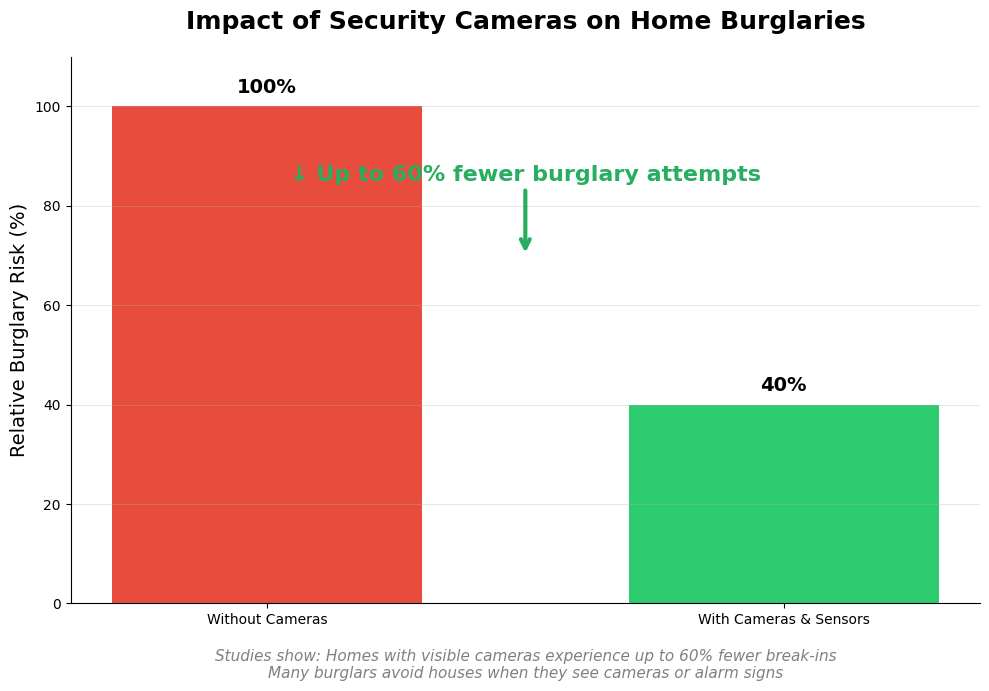

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Данные для диаграммы (можно менять)
categories = ['Without Cameras', 'With Cameras & Sensors']
values = [100, 40]                    # 100% = без камер, 40% = с камерами
reduction = 60                        # процент уменьшения

# Создаём фигуру
fig, ax = plt.subplots(figsize=(10, 7))

# Цвета: красный для "без", зелёный для "с камерами"
bars = ax.bar(categories, values, color=['#e74c3c', '#2ecc71'], width=0.6)

# Добавляем значения сверху столбиков
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{int(height)}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Заголовок и подписи
ax.set_title('Impact of Security Cameras on Home Burglaries', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('Relative Burglary Risk (%)', fontsize=14)
ax.set_ylim(0, 110)   # чтобы было место для текста сверху

# Большая стрелка и текст уменьшения
ax.annotate(f'↓ Up to {reduction}% fewer burglary attempts',
            xy=(0.5, 70), xytext=(0.5, 85),
            fontsize=16, fontweight='bold', color='#27ae60',
            ha='center', arrowprops=dict(arrowstyle='->', lw=3, color='#27ae60'))

# Дополнительный текст (факты)
ax.text(0.5, -15, 
        'Studies show: Homes with visible cameras experience up to 60% fewer break-ins\n'
        'Many burglars avoid houses when they see cameras or alarm signs',
        ha='center', fontsize=11, style='italic', color='gray')

# Убираем верхнюю и правую рамку
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Показать диаграмму
plt.show()